# 10. Customer group

sử dụng KMean hoặc GMM(nếu distribution phức tạp)

## 1. Setup and Load Dataset

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
# Add project root to path
import os
import sys
sys.path.append(os.path.abspath('../'))
from src.data_loader import load_data, load_raw_data, save_file
from src.splitting import time_train_test_split
from src.evaluation import evaluate

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print(f"Python version: {sys.version.split()[0]}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Python version: 3.10.20
Pandas version: 2.3.3
NumPy version: 2.2.5


In [2]:
# Load raw data using custom loader
try:
    df = load_raw_data()
    print("✅ Data loaded successfully!")
    print(f"📊 Shape: {df.shape}")
    print(f"🕒 Time span: {df.index.min()} → {df.index.max()}")
    print(f"🕒 Frequency: {df.index.freq if df.index.freq else 'Not set'}")
except Exception as e:
    print(f"❌ Error: {e}")

👉 Loading: data\raw\electricity_data.parquet
✅ Data loaded successfully!
📊 Shape: (140256, 370)
🕒 Time span: 2011-01-01 00:15:00 → 2015-01-01 00:00:00
🕒 Frequency: Not set


In [3]:
import pandas as pd

# ensure datetime
df.index = pd.to_datetime(df.index)

# sort
df = df.sort_index()

# đảm bảo đều 15min
df = df.asfreq("15min").interpolate()

# resample → hourly
df_hourly = df.resample("1h").sum()

# set freq
df_hourly = df_hourly.asfreq("h")

print("Done resample")
print(df_hourly.shape)
print(df_hourly.index.freq)

Done resample
(35065, 370)
<Hour>


## Xử lý giá trị 0

In [4]:
# 1. cắt năm đầu
df_clean = df_hourly["2012-01-01":].copy()
print(df_clean.head(5))
# 2. fix freq
df_clean = df_clean.asfreq("h")


                        MT_001     MT_002      MT_003      MT_004      MT_005       MT_006     MT_007       MT_008  \
Timestamp                                                                                                            
2012-01-01 00:00:00  12.690355  68.278805  231.972198  412.601626  213.414634  1053.571429  27.133974   838.383838   
2012-01-01 01:00:00  16.497462  90.327169  309.296264  552.845528  289.024390  1360.119048  27.133974  1101.010101   
2012-01-01 02:00:00  19.035533  93.883357  309.296264  556.910569  269.512195  1238.095238  27.699265  1023.569024   
2012-01-01 03:00:00  17.766497  88.904694  309.296264  441.056911  210.975610   842.261905  22.611645   831.649832   
2012-01-01 04:00:00  19.035533  87.482219  309.296264  343.495935  189.024390   645.833333  14.132278   730.639731   

                         MT_009      MT_010      MT_011  MT_012      MT_013      MT_014  MT_015      MT_016  \
Timestamp                                                     

## Chia features để phân nhóm

In [5]:
# features
zero_ratio = (df_clean == 0).mean(axis=0)
active_hours = (df_clean > 0).sum(axis=0)

total_energy = df_clean.sum(axis=0)
mean_energy = df_clean.mean(axis=0)

features = pd.DataFrame({
    "customer_id": df_clean.columns,
    "total_energy": total_energy.values,
    "mean_energy": mean_energy.values,
    "zero_ratio": zero_ratio.values,
    "active_hours": active_hours.values,
    "avg_when_active": total_energy.values / (active_hours.values + 1e-8)
})

features["log_total_energy"] = np.log1p(features["total_energy"])
features["log_mean_energy"] = np.log1p(features["mean_energy"])
# 2. scale
feature_cols = [
    "log_total_energy",
    "log_mean_energy",
    "zero_ratio",
    "avg_when_active"
]

X = features[feature_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Phân loại (bằng KMeans)

In [6]:
# KMeans clustering
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
features["cluster"] = kmeans.fit_predict(X_scaled)

# reorder cluster theo total_energy
cluster_order = features.groupby("cluster")["total_energy"].mean().sort_values().index
mapping = {old: new for new, old in enumerate(cluster_order)}
features["cluster"] = features["cluster"].map(mapping)

# summary
cluster_summary = features.groupby("cluster")[feature_cols].mean()
print(cluster_summary)
print("\n Số lượng khách mỗi cluster:")
print(features["cluster"].value_counts().sort_index())

         log_total_energy  log_mean_energy  zero_ratio  avg_when_active
cluster                                                                
0               14.514503         4.361744    0.607213       380.950522
1               16.029307         5.856293    0.008097       460.386779
2               18.427043         8.249882    0.015916      8671.944657

 Số lượng khách mỗi cluster:
cluster
0     41
1    237
2     92
Name: count, dtype: int64


c:\Users\XPS\anaconda3\envs\time\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


## Phân loại (bằng GMM)

In [7]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=3,
    covariance_type='full',
    random_state=42
)

gmm.fit(X_scaled)

# hard label
features["cluster_gmm"] = gmm.predict(X_scaled)

# soft probability
probs = gmm.predict_proba(X_scaled)
features["confidence"] = probs.max(axis=1)

# 6. SORT CLUSTER (low → high)
cluster_order = (
    features.groupby("cluster_gmm")["total_energy"]
    .mean()
    .sort_values()
    .index
)

mapping = {old: new for new, old in enumerate(cluster_order)}
features["cluster_gmm"] = features["cluster_gmm"].map(mapping)

# 7. OUTPUT
print("Số lượng khách mỗi cluster (GMM):")
print(features["cluster_gmm"].value_counts().sort_index())

print("\nCluster summary (GMM):")
print(features.groupby("cluster_gmm")[feature_cols].mean())

print("\nSample kết quả:")
print(features[["customer_id", "cluster_gmm", "confidence"]].head())

# UNCERTAIN USERS
uncertain = features[features["confidence"] < 0.6]

print("\nKH không rõ cluster:")
print(uncertain[["customer_id", "confidence"]].head())

Số lượng khách mỗi cluster (GMM):
cluster_gmm
0     63
1    271
2     36
Name: count, dtype: int64

Cluster summary (GMM):
             log_total_energy  log_mean_energy  zero_ratio  avg_when_active
cluster_gmm                                                                
0                   14.664988         4.508913    0.425066       325.584912
1                   16.495127         6.320410    0.000169       856.191679
2                   19.312630         9.135263    0.040395     18611.382002

Sample kết quả:
  customer_id  cluster_gmm  confidence
0      MT_001            0    1.000000
1      MT_002            1    0.999900
2      MT_003            0    1.000000
3      MT_004            1    0.999997
4      MT_005            1    0.999983

KH không rõ cluster:
    customer_id  confidence
365      MT_366    0.586302


c:\Users\XPS\anaconda3\envs\time\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


## Số khách hàng khác nhau

In [8]:
diff = (features["cluster"] != features["cluster_gmm"]).sum()
print(f"Số KH khác nhau: {diff}")

Số KH khác nhau: 78


## So sánh 2 phương pháp

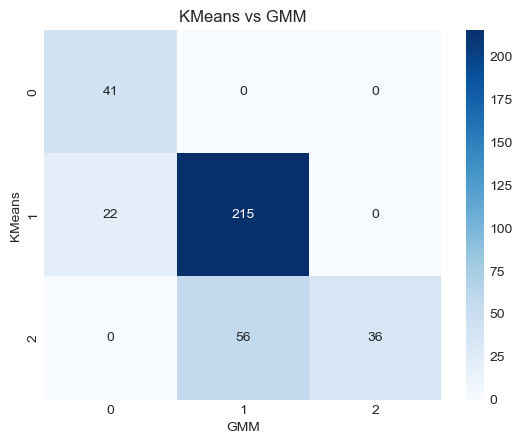

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    features["cluster"],
    features["cluster_gmm"]
)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("GMM")
plt.ylabel("KMeans")
plt.title("KMeans vs GMM")
plt.show()

In [10]:
# so sánh chất lượng
from sklearn.metrics import silhouette_score

score_kmeans = silhouette_score(X_scaled, features["cluster"])
score_gmm = silhouette_score(X_scaled, features["cluster_gmm"])

print("Silhouette KMeans:", score_kmeans)
print("Silhouette GMM:", score_gmm)

Silhouette KMeans: 0.5502582721779721
Silhouette GMM: 0.5002423126151999


## Chia Train/Test

In [11]:
# Chia train-test theo dataset chưa cắt năm đầu
train_df = df["2011-01-01":"2013-12-31"]
test_df  = df["2014-01-01":"2015-01-01"]
train_df_h = train_df.resample("1h").mean()
test_df_h = test_df.resample("1h").mean()
print(train_df_h.index.min(), train_df_h.index.max())
print(test_df_h.index.min(), test_df_h.index.max())

2011-01-01 00:00:00 2013-12-31 23:00:00
2014-01-01 00:00:00 2015-01-01 00:00:00


In [12]:
# gộp dữ liệu cluster KMeans vào train/test
cluster_series_train = {}
for c in sorted(features["cluster"].unique()):
    ids = features[features["cluster"] == c]["customer_id"]
    subset = train_df_h[ids]
    ts = subset.mean(axis=1)
    cluster_series_train[c] = ts

cluster_series_test = {}
for c in sorted(features["cluster"].unique()):
    ids = features[features["cluster"] == c]["customer_id"]
    subset = test_df_h[ids]
    ts = subset.mean(axis=1)
    cluster_series_test[c] = ts

for c in cluster_series_train:
    print(f"\nCluster {c}")
    print("Train:", cluster_series_train[c].shape)
    print("Test :", cluster_series_test[c].shape)


Cluster 0
Train: (26304,)
Test : (8761,)

Cluster 1
Train: (26304,)
Test : (8761,)

Cluster 2
Train: (26304,)
Test : (8761,)


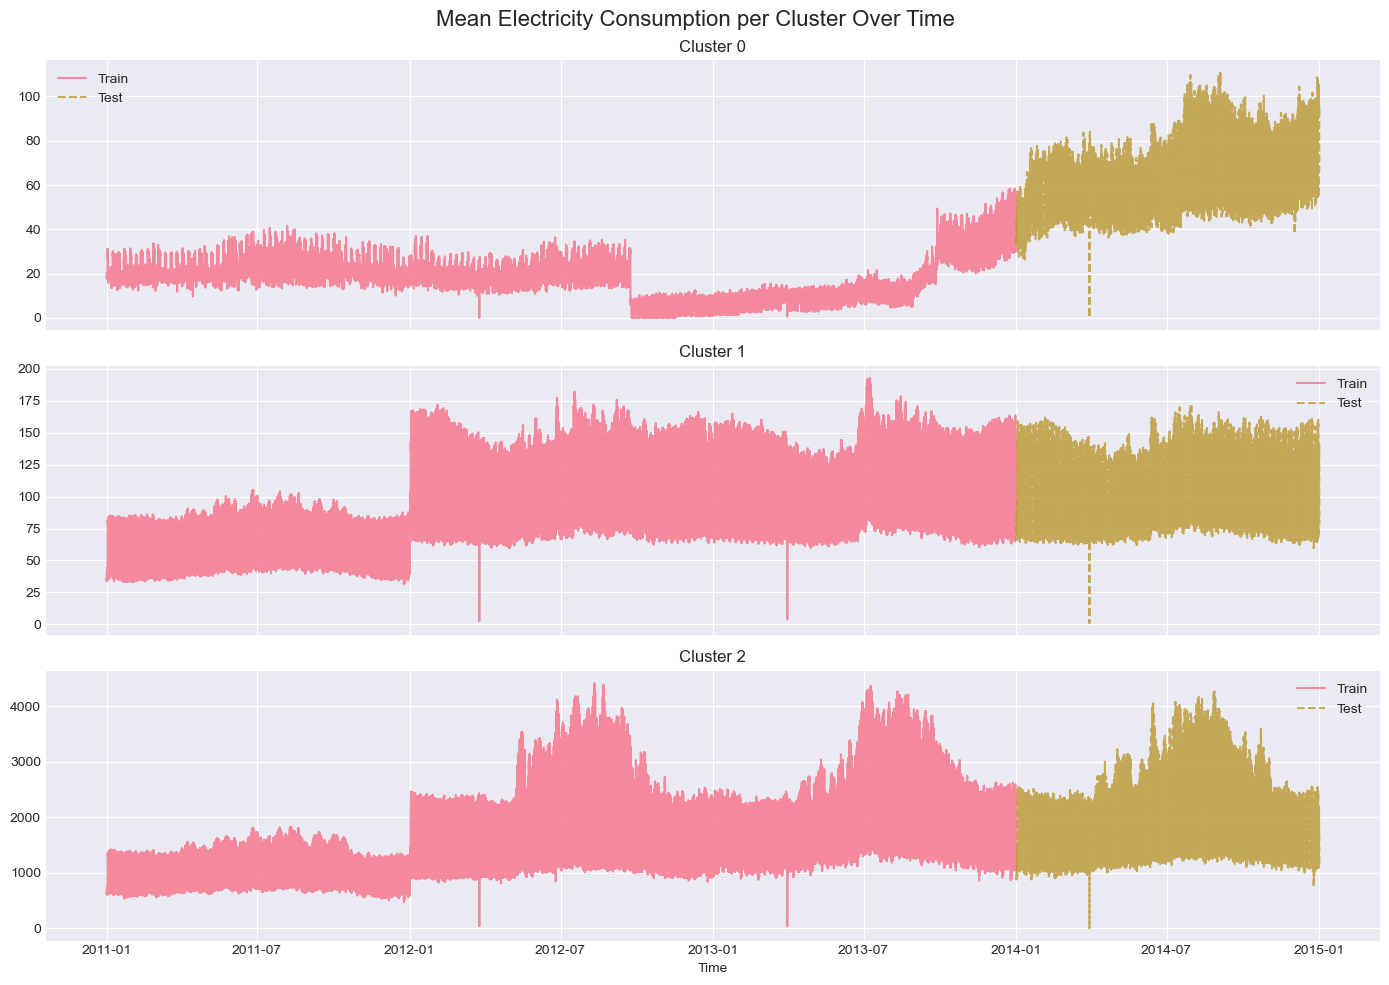

In [13]:
import matplotlib.pyplot as plt

clusters = sorted(cluster_series_train.keys())
fig, axes = plt.subplots(len(clusters), 1, figsize=(14, 10), sharex=True)

for i, c in enumerate(clusters):
    ax = axes[i]
    # train
    ax.plot(cluster_series_train[c], label="Train", alpha=0.8)
    
    # test
    ax.plot(cluster_series_test[c], linestyle="--", label="Test", alpha=0.8)
    
    ax.set_title(f"Cluster {c}")
    ax.legend()
plt.suptitle("Mean Electricity Consumption per Cluster Over Time", fontsize=16)
plt.xlabel("Time")
plt.tight_layout()
plt.show()

## Train model SARIMAX

Done preparing clustered train/test series.
Cluster 0: train=(1096,), test=(366,)
Cluster 1: train=(1096,), test=(366,)
Cluster 2: train=(1096,), test=(366,)

=== Comparison Table ===
    cluster            model            MAE           RMSE    MAPE(%)
1         0  SeasonalNaive_7     295.100841     501.250937  29.182986
2         0      HoltWinters    1662.355796    1795.180053  45.367014
0         0            Naive    2128.701344    2286.506259  49.228451
3         0           SARIMA    1253.189746    1628.696931  60.644610
5         1  SeasonalNaive_7     366.103862     636.592155  26.565152
7         1           SARIMA    1238.354359    1563.314277  42.308582
4         1            Naive     626.425589     953.283454  42.448785
6         1      HoltWinters     682.319697    1045.744610  49.266070
9         2  SeasonalNaive_7   11057.307487   16554.020482  28.497983
11        2           SARIMA  102082.090711  118667.500774  55.264249
8         2            Naive   33842.638722   

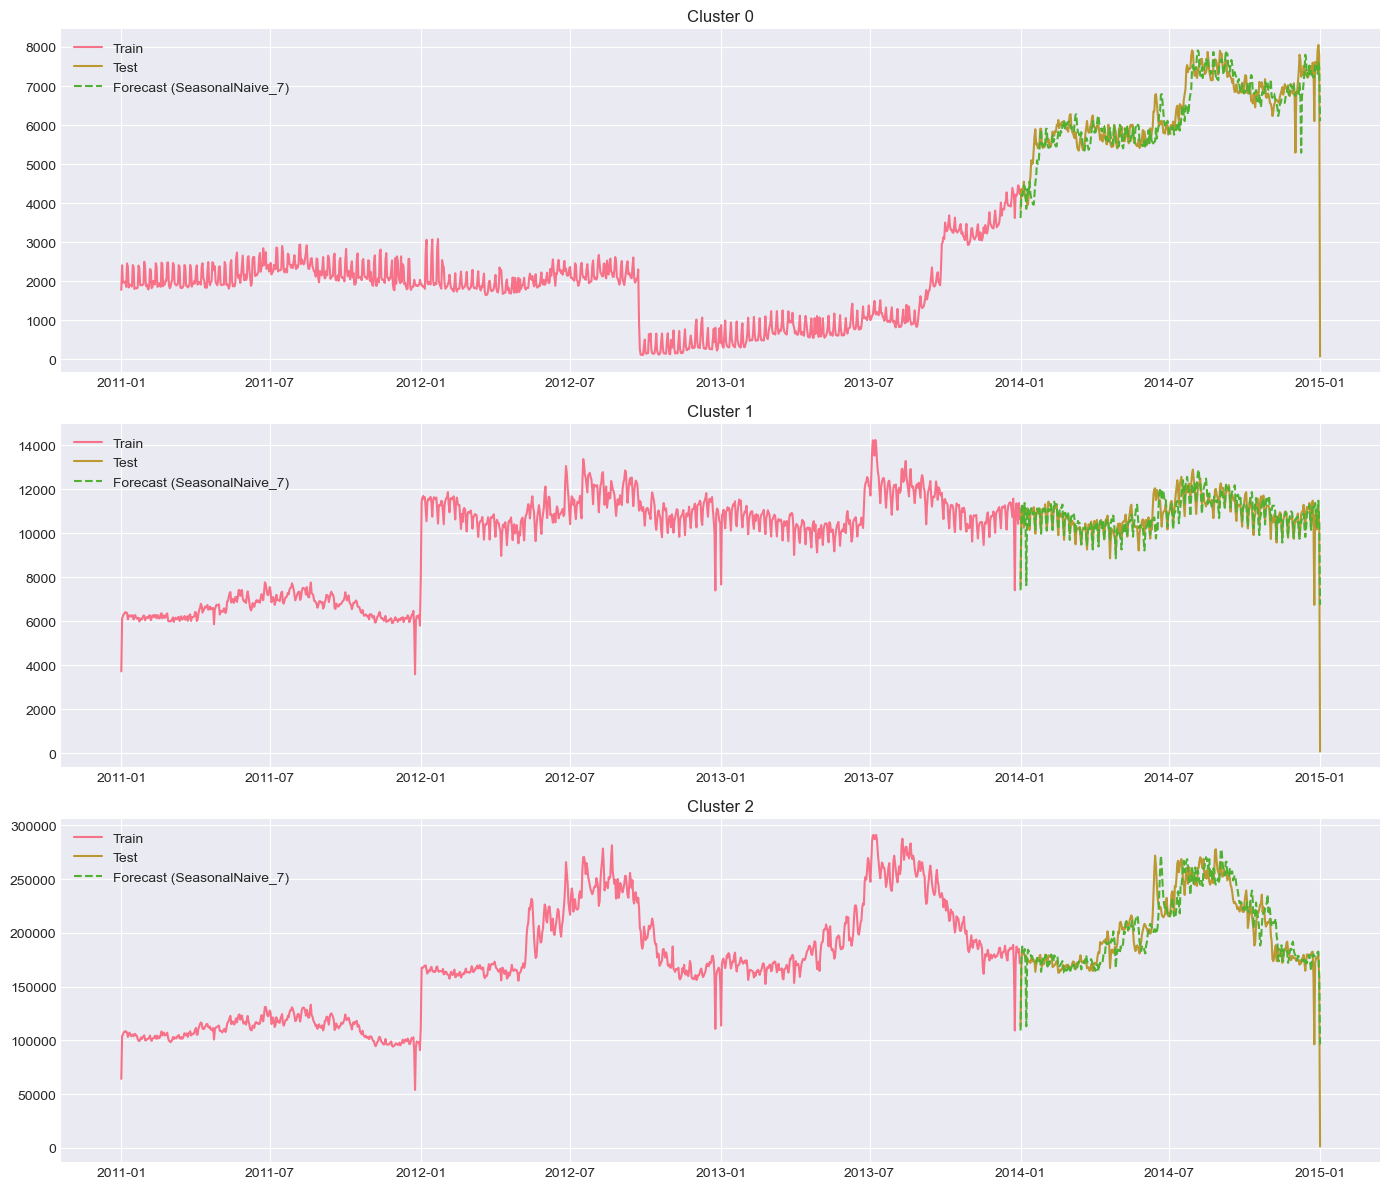

In [14]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# =========================
# 0. HELPER
# =========================
def evaluate_forecast(y_true, y_pred):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred, index=y_true.index).astype(float)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true.replace(0, np.nan)))) * 100

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE(%)": mape
    }

# =========================
# 1. PREPARE DATA
# =========================
# đảm bảo datetime index
df = df.copy()
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# nếu dữ liệu chưa có freq thì cứ giữ nguyên, rồi resample daily
# dùng mean hoặc sum tùy mục tiêu:
# - mean: load trung bình nhóm
# - sum : tổng load toàn nhóm
agg_func = "mean"

# split theo năm:
# train: 2011 -> 2013
# test : năm cuối (2015)
train_df = df.loc["2011-01-01":"2013-12-31"]
test_df  = df.loc["2014-01-01":"2015-01-01"]

# gộp theo cluster trước, rồi resample daily
cluster_series_train = {}
cluster_series_test = {}

for c in sorted(features["cluster"].unique()):
    ids = features.loc[features["cluster"] == c, "customer_id"]

    if agg_func == "mean":
        ts_train = train_df[ids].mean(axis=1)
        ts_test = test_df[ids].mean(axis=1)
    else:
        ts_train = train_df[ids].sum(axis=1)
        ts_test = test_df[ids].sum(axis=1)

    # resample daily để statistical models nhẹ hơn
    ts_train = ts_train.resample("D").sum()
    ts_test = ts_test.resample("D").sum()

    cluster_series_train[c] = ts_train
    cluster_series_test[c] = ts_test

print("Done preparing clustered train/test series.")
for c in cluster_series_train:
    print(f"Cluster {c}: train={cluster_series_train[c].shape}, test={cluster_series_test[c].shape}")

# =========================
# 2. TRAIN + FORECAST
# Models:
# - Naive
# - Seasonal Naive (lag 7)
# - Holt-Winters
# - SARIMA
# =========================
all_results = []
all_forecasts = {}

for c in sorted(cluster_series_train.keys()):
    train_ts = cluster_series_train[c].astype(float)
    test_ts = cluster_series_test[c].astype(float)

    cluster_forecasts = {}

    # -------------------------
    # 2.1 Naive
    # -------------------------
    naive_value = train_ts.iloc[-1]
    naive_pred = pd.Series([naive_value] * len(test_ts), index=test_ts.index)
    cluster_forecasts["Naive"] = naive_pred

    # -------------------------
    # 2.2 Seasonal Naive (lag 7 days)
    # -------------------------
    seasonal_naive_pred = []
    full_ts = pd.concat([train_ts, test_ts])

    for t in test_ts.index:
        ref_t = t - pd.Timedelta(days=7)
        if ref_t in full_ts.index:
            seasonal_naive_pred.append(full_ts.loc[ref_t])
        else:
            seasonal_naive_pred.append(train_ts.iloc[-7])

    seasonal_naive_pred = pd.Series(seasonal_naive_pred, index=test_ts.index)
    cluster_forecasts["SeasonalNaive_7"] = seasonal_naive_pred

    # -------------------------
    # 2.3 Holt-Winters
    # -------------------------
    try:
        hw_model = ExponentialSmoothing(
            train_ts,
            trend="add",
            seasonal="add",
            seasonal_periods=7
        )
        hw_fit = hw_model.fit(optimized=True)
        hw_pred = hw_fit.forecast(len(test_ts))
        hw_pred.index = test_ts.index
        cluster_forecasts["HoltWinters"] = hw_pred
    except Exception as e:
        print(f"Holt-Winters failed on cluster {c}: {e}")

    # -------------------------
    # 2.4 SARIMA
    # daily seasonality weekly => s=7
    # -------------------------
    try:
        sarima_model = SARIMAX(
            train_ts,
            order=(0, 1, 0),
            seasonal_order=(1, 1, 1, 7),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        sarima_fit = sarima_model.fit(disp=False)
        sarima_pred = sarima_fit.get_forecast(steps=len(test_ts)).predicted_mean
        sarima_pred.index = test_ts.index
        cluster_forecasts["SARIMA"] = sarima_pred
    except Exception as e:
        print(f"SARIMA failed on cluster {c}: {e}")

    # lưu forecast
    all_forecasts[c] = cluster_forecasts

    # evaluate
    for model_name, pred in cluster_forecasts.items():
        metrics = evaluate_forecast(test_ts, pred)
        row = {
            "cluster": c,
            "model": model_name,
            **metrics
        }
        all_results.append(row)

# =========================
# 3. RESULTS TABLE
# =========================
results_df = pd.DataFrame(all_results).sort_values(["cluster", "MAPE(%)"])
print("\n=== Comparison Table ===")
print(results_df)

# best model per cluster
best_per_cluster = results_df.loc[results_df.groupby("cluster")["MAPE(%)"].idxmin()]
print("\n=== Best model per cluster ===")
print(best_per_cluster)

# =========================
# 4. PLOT
# =========================
clusters = sorted(cluster_series_train.keys())

fig, axes = plt.subplots(len(clusters), 1, figsize=(14, 4 * len(clusters)), sharex=False)
if len(clusters) == 1:
    axes = [axes]

for i, c in enumerate(clusters):
    ax = axes[i]

    train_ts = cluster_series_train[c]
    test_ts = cluster_series_test[c]

    ax.plot(train_ts.index, train_ts.values, label="Train")
    ax.plot(test_ts.index, test_ts.values, label="Test")

    # vẽ best model
    best_model_name = best_per_cluster.loc[best_per_cluster["cluster"] == c, "model"].values[0]
    best_pred = all_forecasts[c][best_model_name]

    ax.plot(best_pred.index, best_pred.values, "--", label=f"Forecast ({best_model_name})")

    ax.set_title(f"Cluster {c}")
    ax.legend()

plt.tight_layout()
plt.show()


## Dự đoán tổng lượng điện tiêu thụ

MAE  : 11411.64
RMSE : 17336.51
MAPE : 28.31%
Accuracy ≈ 71.69%


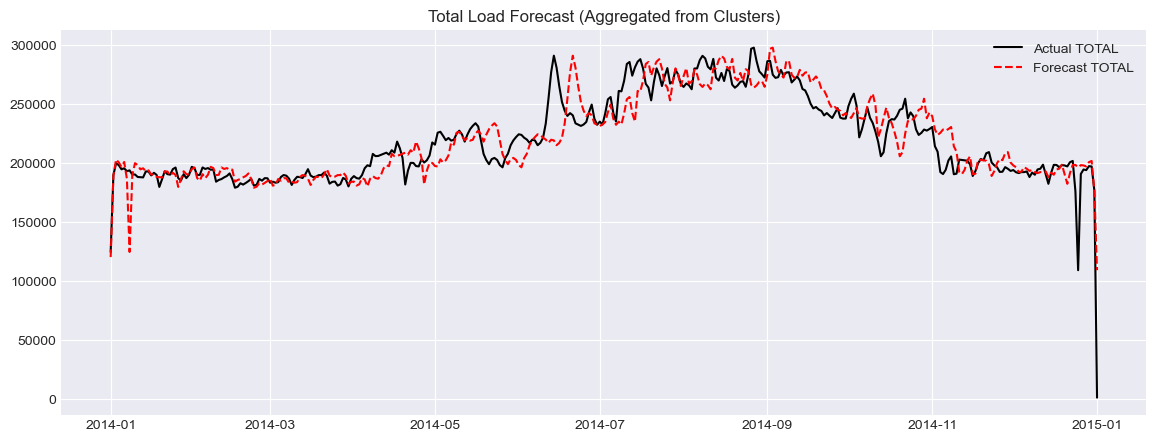

In [15]:
# tổng dự đoán
total_forecast = None

for c in sorted(all_forecasts.keys()):
    
    # lấy best model của cluster c
    best_model_name = best_per_cluster.loc[
        best_per_cluster["cluster"] == c, "model"
    ].values[0]

    pred = all_forecasts[c][best_model_name]

    if total_forecast is None:
        total_forecast = pred.copy()
    else:
        total_forecast += pred
# tổng thực tế
total_actual = None

for c in cluster_series_test:
    ts = cluster_series_test[c]

    if total_actual is None:
        total_actual = ts.copy()
    else:
        total_actual += ts
# evaluate tổng
from sklearn.metrics import mean_absolute_error
import numpy as np

mae = mean_absolute_error(total_actual, total_forecast)
rmse = np.sqrt(((total_actual - total_forecast) ** 2).mean())
mape = np.mean(np.abs((total_actual - total_forecast) / (total_actual + 1e-8))) * 100

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")
print(f"Accuracy ≈ {100 - mape:.2f}%")
# plot
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

plt.plot(total_actual.index, total_actual.values, label="Actual TOTAL", color="black")
plt.plot(total_forecast.index, total_forecast.values, "--", label="Forecast TOTAL", color="red")

plt.legend()
plt.title("Total Load Forecast (Aggregated from Clusters)")
plt.show()